# 1. Introduction to Linear Regression

**What is Linear Regression?**
Linear Regression is one of the most fundamental and widely used machine learning algorithms. It is a supervised learning algorithm that models the linear relationship between a dependent variable (target) and one or more independent variables (features).

**Why it is used & What type of problem it solves**
It is used to predict a continuous, numerical outcome based on input features. It helps us answer questions like "How much?" or "How many?". 

**Regression vs Classification**
* **Regression:** Predicts a continuous output (e.g., $250,000, 72.5, -10.2).
* **Classification:** Predicts a categorical output (e.g., "Spam" or "Not Spam", "Dog" or "Cat").

**Real-world applications**
* **House price prediction:** Based on size, bedrooms, and location.
* **Salary prediction:** Based on years of experience and education level.
* **Sales prediction:** Based on advertising spend.
* **Temperature prediction:** Based on humidity and pressure.

> Key Idea: Linear Regression assumes that the input features and the target variable share a linear relationship. The basic idea is:
> 
> Input Features → Linear Relationship → Continuous Prediction


# 2. Simple Linear Regression

**Simple Linear Regression** involves predicting a target variable ($y$) using exactly **one** input feature ($X$).

**The Equation of a Straight Line**
$$ y = mx + b $$

Where:
* **$y$**: The predicted continuous value (dependent variable).
* **$x$**: The input feature (independent variable).
* **$m$**: The slope (coefficient).
* **$b$**: The intercept (bias).

> Important: 
> * **Slope ($m$) intuitively:** It tells us how much $y$ is expected to change when $x$ increases by exactly 1 unit.
> * **Intercept ($b$) intuitively:** It tells us the expected value of $y$ when $x = 0$.


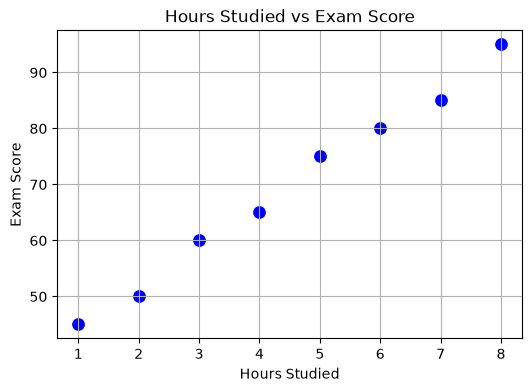

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create a simple dataset
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8],
    'Exam_Score': [45, 50, 60, 65, 75, 80, 85, 95]
}

df_simple = pd.DataFrame(data)

# Visualize the relationship
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df_simple, color='blue', s=100)
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()


# 3. Understanding the Regression Line

**What the regression line represents**
The regression line (or "line of best fit") is a straight line drawn through the center of the data points that best represents the trend of the data. 

* **Positive relationship:** As $X$ increases, $y$ increases (slope is positive).
* **Negative relationship:** As $X$ increases, $y$ decreases (slope is negative).
* **No linear relationship:** The line is flat, meaning $X$ doesn't help predict $y$ (slope is close to 0).

**How is the best-fit line selected?**
Out of infinite possible lines we could draw, the algorithm selects the one that minimizes the total error (the distance between the actual data points and the points predicted by the line).


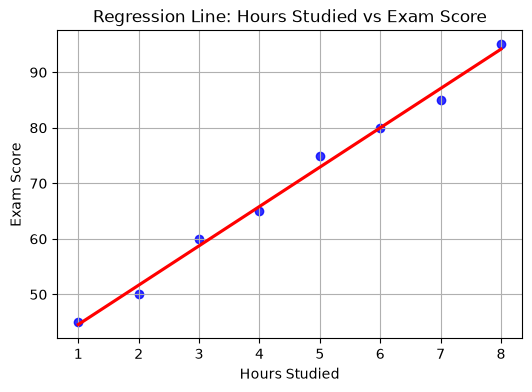

In [8]:
# Let's draw a simple regression line
plt.figure(figsize=(6, 4))
sns.regplot(x='Hours_Studied', y='Exam_Score', data=df_simple, ci=None, color='blue', line_kws={"color": "red"})
plt.title('Regression Line: Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()


# 4. Cost Function / Loss Function

**Why do we need a cost function?**
We need a mathematical way to evaluate "how wrong" our line is. A cost function takes the model's predictions and the actual data, and outputs a single number representing the total error. The goal of machine learning is to minimize this cost.

**Mean Squared Error (MSE)**
The most common cost function for Linear Regression.

$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Where:
* **$y_i$**: The actual value.
* **$\hat{y}_i$**: The predicted value.
* **$y_i - \hat{y}_i$**: The residual or error.
* **$(y_i - \hat{y}_i)^2$**: The squared error.

> Key Idea: Why do we square the errors? 
> 1. It ensures all errors are positive (so negative and positive errors don't cancel out). 
> 2. It heavily penalizes large errors (e.g., an error of 10 is penalized 100 times more than an error of 1).


In [9]:
from sklearn.metrics import mean_squared_error

# Small numerical example
actual_values = np.array([45, 50, 60, 65])
predicted_values = np.array([48, 48, 58, 68]) # Imagine our model guessed these

# Manual Calculation
errors = actual_values - predicted_values
squared_errors = errors ** 2
manual_mse = squared_errors.mean()

# Scikit-learn Calculation
sklearn_mse = mean_squared_error(actual_values, predicted_values)

print(f"Manual MSE: {manual_mse}")
print(f"Scikit-learn MSE: {sklearn_mse}")


Manual MSE: 6.5
Scikit-learn MSE: 6.5


# 5. Ordinary Least Squares (OLS)

**Ordinary Least Squares (OLS)** is the mathematical method used to find the best-fit line.

* **Residuals:** The vertical distance between the actual point and the regression line.
* **Sum of Squared Errors (SSE):** OLS squares all these residuals and adds them up.
* **Best-fit line:** OLS uses calculus/linear algebra to instantly calculate the exact slope and intercept that produce the absolute minimum Sum of Squared Errors.

> Key Idea: OLS provides a direct mathematical solution (a closed-form equation) to find the best parameters without needing iterative learning.


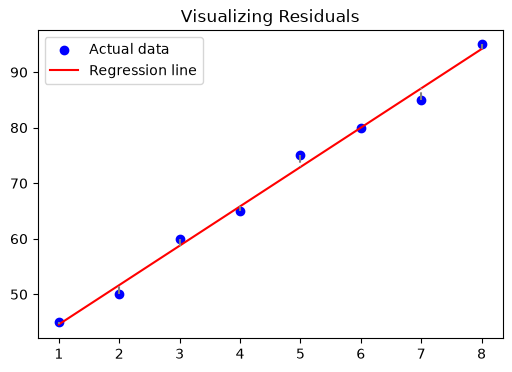

In [10]:
# Visualizing Residuals
X = df_simple['Hours_Studied']
y = df_simple['Exam_Score']

# Fit a quick line using numpy polyfit
m, b = np.polyfit(X, y, 1)
y_pred = m*X + b

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', label='Actual data')
plt.plot(X, y_pred, color='red', label='Regression line')

# Draw lines representing residuals
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y[i], y_pred[i]], color='gray', linestyle='--')

plt.title('Visualizing Residuals')
plt.legend()
plt.show()


# 6. Gradient Descent Intuition

While OLS finds the answer instantly using math, **Gradient Descent** is an iterative optimization algorithm used when datasets are too massive or when models are too complex (like Deep Learning) for direct math formulas.

**How it works (Intuitively):**
1. **Starting point:** Pick a random slope and intercept.
2. **Cost function:** Calculate how bad your line is (MSE).
3. **Gradient:** Calculate the slope (derivative) of the cost function at your current position. This tells you which direction is "downhill".
4. **Learning rate:** Take a small step downhill. The size of the step is the learning rate.
5. **Updating parameters:** Adjust the slope and intercept.
6. **Reaching minimum cost:** Repeat until you reach the bottom of the "valley" (minimum error).

**The Basic Update Rule:**
$$ parameter = parameter - (learning\_rate \times gradient) $$

> Remember: A learning rate too high causes the model to bounce around and never settle. A learning rate too small makes training take forever.


# 7. Simple Linear Regression from Scratch

Let's implement Gradient Descent for Simple Linear Regression using pure NumPy.


Final Estimated Slope (m): 2.0039
Final Estimated Intercept (b): 0.9860


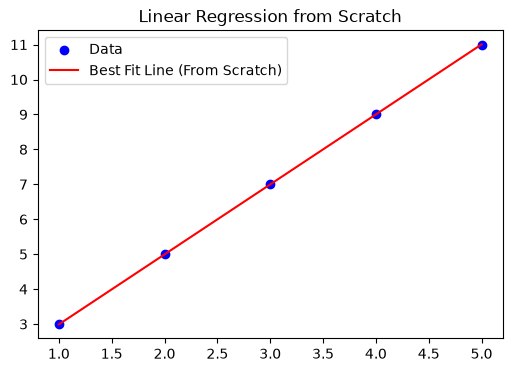

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset
X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11]) # True relation: y = 2x + 1

# 2. Initialize parameters randomly
m = 0.0 # slope
b = 0.0 # intercept

learning_rate = 0.01
epochs = 1000
n = float(len(X))

# Store history for visualization
cost_history = []

for i in range(epochs):
    # 3. Prediction
    y_pred = m*X + b
    
    # 4. Calculate error (Cost Function)
    cost = (1/n) * sum([val**2 for val in (y - y_pred)])
    cost_history.append(cost)
    
    # 5. Calculate Gradients (Derivatives of MSE with respect to m and b)
    D_m = (-2/n) * sum(X * (y - y_pred))
    D_b = (-2/n) * sum(y - y_pred)
    
    # 6. Update parameters
    m = m - learning_rate * D_m
    b = b - learning_rate * D_b

print(f"Final Estimated Slope (m): {m:.4f}")
print(f"Final Estimated Intercept (b): {b:.4f}")

# 7. Plot final regression line
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, m*X + b, color='red', label='Best Fit Line (From Scratch)')
plt.legend()
plt.title('Linear Regression from Scratch')
plt.show()


# 8. Multiple Linear Regression

**Simple vs Multiple Linear Regression**
* **Simple:** One feature predicts the target (e.g., Size → Price).
* **Multiple:** Two or more features predict the target (e.g., Size, Bedrooms, Age → Price).

**The Equation**
$$ y = b_0 + b_1x_1 + b_2x_2 + ... + b_nx_n $$

* **$b_0$**: Intercept (bias).
* **$b_1, b_2, ...$**: Coefficients (weights) for each respective feature.
* **$x_1, x_2, ...$**: The multiple features.


In [12]:
# Creating a small multiple feature dataset
data_multi = {
    'Area_sqft': [1500, 2000, 1200, 1800, 2500],
    'Bedrooms': [3, 4, 2, 3, 4],
    'Age_years': [10, 5, 20, 2, 8],
    'Location_Score': [8, 9, 6, 9, 10],
    'Price_1000s': [300, 450, 200, 400, 500]
}

df_multi = pd.DataFrame(data_multi)
display(df_multi)

# X will have 4 columns, y will have 1 column.


,Area_sqft,Bedrooms,Age_years,Location_Score,Price_1000s
0,1500,3,10,8,300
1,2000,4,5,9,450
2,1200,2,20,6,200
3,1800,3,2,9,400
4,2500,4,8,10,500


# 9. Linear Regression with Scikit-learn

In practice, we rarely code ML algorithms from scratch. We use `scikit-learn`.


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Prepare X and y
X = df_multi[['Area_sqft', 'Bedrooms', 'Age_years', 'Location_Score']]
y = df_multi['Price_1000s']

# 2. Train-test split (We'll use a tiny test set since data is so small)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create model
model = LinearRegression()

# 4. Fit model (This is where the model learns parameters m and b using OLS)
model.fit(X_train, y_train)

# 5. Predict (Using the learned parameters on unseen data)
y_pred = model.predict(X_test)

print("Predictions for Test Set:", y_pred)
print("Actual values for Test Set:", y_test.values)


Predictions for Test Set: [418.52836663]
Actual values for Test Set: [450]


# 10. Understanding Model Coefficients

Once the model has called `fit()`, it has learned the parameters.

* **`model.coef_`**: The slopes (weights) for each feature.
* **`model.intercept_`**: The baseline value when all features are 0.

> Key Idea: 
> * A **positive coefficient** means: As this feature increases, the target increases (e.g., larger Area = higher Price).
> * A **negative coefficient** means: As this feature increases, the target decreases (e.g., older Age = lower Price).


In [14]:
print(f"Intercept (b0): {model.intercept_:.2f}\n")

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
    
# Interpretation: For every 1 unit increase in Area_sqft, the price increases by 'coef' (assuming all else constant).


Intercept (b0): 102.67

Coefficients:
Area_sqft: 0.2046
Bedrooms: -6.1824
Age_years: -5.4049
Location_Score: -4.6274


# 11. Train-Test Split for Regression

**Why is it important?**
If we train and evaluate our model on the exact same data, the model might just memorize the answers (Overfitting). To see if our model generalizes well to the real world, we must hide a portion of the data (Test data) during training, and only use it for final evaluation.

**Demonstration with `random_state`**
`random_state=42` ensures the random shuffle is identical every time you run the cell.


In [15]:
# Standard train-test split pattern
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (4, 4)
Testing data shape: (1, 4)


# 12. Regression Evaluation Metrics

How do we score our regression model?

### MAE (Mean Absolute Error)
$$ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$
* **Intuition:** The average absolute difference between predicted and actual values. Very easy to understand (e.g., "We are off by $5,000 on average").

### MSE (Mean Squared Error)
$$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
* **Intuition:** Penalizes large errors heavily. Useful for optimization, but hard to interpret the number (the units are squared).

### RMSE (Root Mean Squared Error)
$$ RMSE = \sqrt{MSE} $$
* **Intuition:** Solves the MSE unit problem by taking the square root. Now the error is back in the original units. Very commonly used.

### R² Score (Coefficient of Determination)
* **Intuition:** Measures how much of the variance in the target variable is explained by the features. Ranges from 0 to 1 (or negative if the model is worse than a horizontal line).
    * `R² = 1`: Perfect predictions.
    * `R² = 0`: The model is no better than simply guessing the average (mean) value every time.


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming y_test and y_pred from previous section
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Or use squared=False in sklearn
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


MAE:  31.4716
MSE:  990.4637
RMSE: 31.4716
R²:   nan


c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


# 13. Manual Metric Calculation

Let's reinforce the math by calculating metrics manually using NumPy.


In [17]:
y_act = np.array([100, 150, 200, 250])
y_pre = np.array([110, 140, 210, 260])

n = len(y_act)
errors = y_act - y_pre

# Manual MAE
manual_mae = np.sum(np.abs(errors)) / n

# Manual MSE
manual_mse = np.sum(errors ** 2) / n

# Manual RMSE
manual_rmse = np.sqrt(manual_mse)

print(f"Manual MAE: {manual_mae} | Sklearn: {mean_absolute_error(y_act, y_pre)}")
print(f"Manual MSE: {manual_mse} | Sklearn: {mean_squared_error(y_act, y_pre)}")
print(f"Manual RMSE: {manual_rmse:.2f} | Sklearn: {np.sqrt(mean_squared_error(y_act, y_pre)):.2f}")


Manual MAE: 10.0 | Sklearn: 10.0
Manual MSE: 100.0 | Sklearn: 100.0
Manual RMSE: 10.00 | Sklearn: 10.00


# 14. Residual Analysis

**What is a residual?**
`Residual = Actual - Predicted`
It is the error for a single data point.

**Why residuals matter?**
By plotting residuals, we can check if our model is truly capturing the pattern, or if it missed something.

**Good residual behavior:**
Residuals should look like random noise scattered around 0. No clear patterns.

**Unusual patterns indicate:**
* A curve/U-shape: The relationship is not linear (need polynomial regression).
* A cone shape: Heteroscedasticity (variance of errors is not constant).


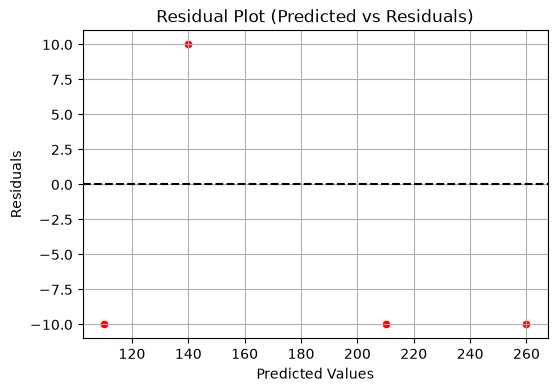

In [18]:
plt.figure(figsize=(6, 4))
residuals = y_act - y_pre
sns.scatterplot(x=y_pre, y=residuals, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot (Predicted vs Residuals)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()


# 15. Assumptions of Linear Regression

Linear Regression mathematically assumes certain conditions about the data. If these are violated, the model's predictions and coefficients might be unreliable.

1. **Linear relationship:** The true relationship between X and y must be a straight line.
2. **Independence of observations:** Data points should not influence each other (e.g., time series data violates this).
3. **Homoscedasticity:** The spread (variance) of residuals should be constant across all predicted values (no cone shapes in residual plots).
4. **Normally distributed residuals:** The errors should roughly follow a bell curve (especially important for calculating confidence intervals).
5. **Low multicollinearity:** The input features should not be highly correlated with *each other*.


# 16. Multicollinearity

**What is it?**
When two or more input features are highly correlated with each other.

**Why is it a problem?**
The model gets confused about which feature is actually causing the change in the target variable. The coefficients become wildly unstable and lose their interpretability.

**Example:**
Including both "Years of Experience" and "Months of Experience" as separate features.


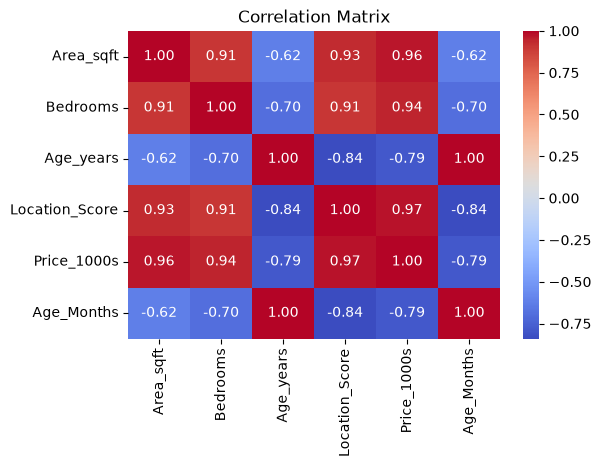

In [21]:
# Correlation Matrix to check for multicollinearity
data = {'Years_Exp': [1, 2, 3, 4], 'Months_Exp': [12, 24, 36, 48], 'Salary': [50000, 60000, 70000, 80000]} # Conceptually
df_multi_col = df_multi.copy()
df_multi_col['Age_Months'] = df_multi_col['Age_years'] * 12 # Artificially create perfect multicollinearity

plt.figure(figsize=(6, 4))
sns.heatmap(df_multi_col.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Notice the perfect 1.0 correlation between Age_years and Age_Months. One of them must be dropped!


# 17. Overfitting and Underfitting in Regression

* **Underfitting (High Bias):** The model is a straight line, but the data is curved. It performs terribly on both training and test data.
* **Good fit:** The model captures the underlying curve.
* **Overfitting (High Variance):** The model tries to hit every single point perfectly, resulting in a wildly complex curve that captures noise. Performs perfectly on training data, but fails completely on test data.


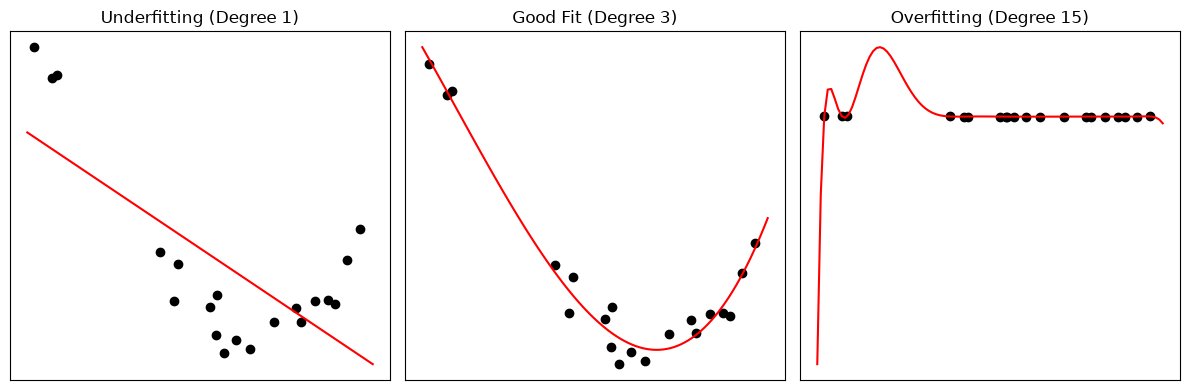

In [22]:
# Visualizing complexity
np.random.seed(0)
x_poly = np.sort(np.random.rand(20))
y_poly = np.cos(1.5 * np.pi * x_poly) + np.random.randn(20) * 0.1

plt.figure(figsize=(12, 4))
titles = ['Underfitting (Degree 1)', 'Good Fit (Degree 3)', 'Overfitting (Degree 15)']
degrees = [1, 3, 15]

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    p = np.poly1d(np.polyfit(x_poly, y_poly, degree))
    x_plot = np.linspace(0, 1, 100)
    plt.scatter(x_poly, y_poly, color='black', label='Data')
    plt.plot(x_plot, p(x_plot), color='red', label='Model')
    plt.title(titles[i])
    plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()


# 18. Polynomial Regression Introduction

**Why a straight line isn't always enough?**
If the relationship is clearly a curve (like $y = x^2$), a standard straight line will underfit.

**Polynomial Features**
We can create new features by squaring or cubing existing features (e.g., $x, x^2, x^3$). We then feed these *polynomial* features into a standard *Linear* Regression model. It's called Linear Regression because it's linear with respect to the *coefficients*, even if the curve drawn is polynomial!


In [23]:
from sklearn.preprocessing import PolynomialFeatures

# Create non-linear data
X_nl = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_nl = np.array([1, 4, 9, 16, 25]) # Perfect square

# Linear Regression (fails)
lin_model = LinearRegression().fit(X_nl, y_nl)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_nl) # Transforms X into [1, x, x^2]

poly_model = LinearRegression().fit(X_poly, y_nl)

print("Linear Model R2:", lin_model.score(X_nl, y_nl))
print("Polynomial Model R2:", poly_model.score(X_poly, y_nl))


Linear Model R2: 0.9625668449197862
Polynomial Model R2: 1.0


# 19. Feature Scaling and Linear Regression

**Is scaling required for Ordinary Linear Regression?**
If you are using Ordinary Least Squares (Scikit-learn's default `LinearRegression`), feature scaling (Standardization/Normalization) is **NOT strictly required**. OLS will calculate the exact same predictions regardless of scale.

**When is scaling required?**
Scaling becomes **absolutely critical** when:
1. You are using Gradient Descent to optimize the model.
2. You are using Regularization (Ridge, Lasso). The penalties in regularization depend heavily on the scale of the coefficients, which depend on the scale of the features.


# 20. Regularization Introduction

**Why regularization is useful?**
When models become too complex (e.g., too many features, high degree polynomials), they overfit. Regularization deliberately adds a "penalty" to the cost function for having large coefficients. This forces the model to keep coefficients small, resulting in a simpler, smoother curve that generalizes better.

### Ridge Regression (L2 Regularization)
* Adds a penalty equal to the sum of the **squared** coefficients.
* Shrinks coefficients towards 0, but rarely makes them exactly 0.

### Lasso Regression (L1 Regularization)
* Adds a penalty equal to the sum of the **absolute** coefficients.
* Can shrink coefficients all the way to exactly 0, effectively performing **feature selection**.

### Elastic Net
* A combination of both L1 and L2 penalties.


In [24]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Syntax comparison (concept only, requires scaled data in reality)
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Example fit (using previous X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

print("Linear Coefs:", model.coef_)
print("Ridge Coefs:", ridge.coef_)
print("Lasso Coefs:", lasso.coef_)


Linear Coefs: [ 0.20462737 -6.18242299 -5.40489453 -4.62736607]
Ridge Coefs: [ 0.19036659 -1.23158538 -4.88110608 -0.58877079]
Lasso Coefs: [ 0.19672449 -7.41398044 -4.95718197 -0.        ]


# 21. Complete Linear Regression Project

Let's bring everything together using the Diabetes dataset from Scikit-Learn.


In [25]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load dataset
diabetes = load_diabetes()

# 3. Convert to DataFrame
df_proj = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_proj['target'] = diabetes.target # A quantitative measure of disease progression

# 4. Inspect data
print(df_proj.head())

# 5. Define X and y
X_proj = df_proj.drop('target', axis=1)
y_proj = df_proj['target']

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_proj, y_proj, test_size=0.2, random_state=42)

# 7. Train Linear Regression model
model_proj = LinearRegression()
model_proj.fit(X_train, y_train)

# 8. Predict
y_pred_proj = model_proj.predict(X_test)

# 9. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred_proj)
mse = mean_squared_error(y_test, y_pred_proj)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_proj)

print(f"\n--- Evaluation Metrics ---")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")

# 10. Analyze coefficients
coef_df = pd.DataFrame({'Feature': X_proj.columns, 'Coefficient': model_proj.coef_})
print(f"\n--- Top Coefficients ---")
print(coef_df.sort_values(by='Coefficient', ascending=False).head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

--- Evaluation Metrics ---
MAE: 42.79
MSE: 2900.19
RMSE: 53.85
R2: 0.4526

--- Top Coefficients ---
  Feature  Coefficient
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902


### Explanation of Results
* An $R^2$ of ~0.45 indicates the model explains about 45% of the variance in disease progression. It's not a perfect model, but there is a clear linear signal.
* The RMSE tells us that our predictions are off by roughly 53 units on average.


# 22. Actual vs Predicted Visualization

A visual way to evaluate regression models is plotting True values against Predicted values.


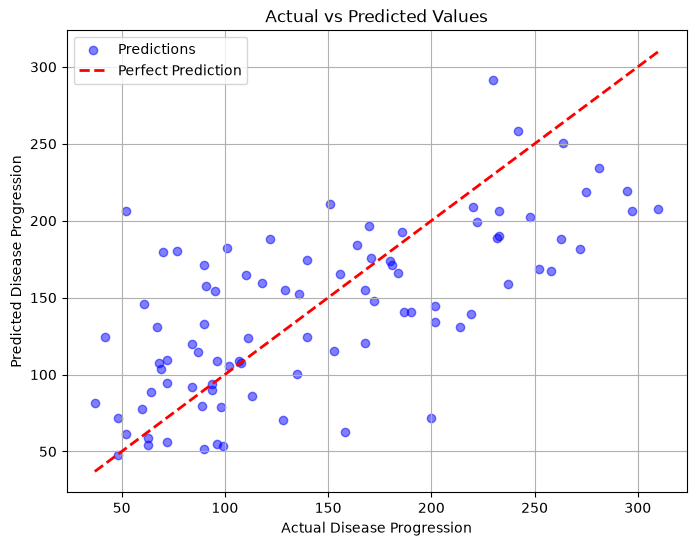

In [26]:
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(y_test, y_pred_proj, color='blue', alpha=0.5, label='Predictions')

# Reference diagonal line (y=x)
max_val = max(y_test.max(), y_pred_proj.max())
min_val = min(y_test.min(), y_pred_proj.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.legend()
plt.grid(True)
plt.show()

# Explanation: Points closer to the red diagonal line mean smaller errors.


# 23. Common Linear Regression Mistakes

> Common Mistake: Let's review what not to do.

1. **Using Linear Regression for non-linear data:**
   * *Wrong:* Fitting a straight line to a U-shaped curve.
   * *Fix:* Use Polynomial Regression or a tree-based model.
2. **Ignoring outliers:**
   * *Wrong:* OLS heavily penalizes large errors, so a single massive outlier can drag the entire line away from the main cluster.
   * *Fix:* Remove or clip outliers before training.
3. **Ignoring multicollinearity:**
   * *Wrong:* Including perfectly correlated features. Coefficients become meaningless.
   * *Fix:* Drop highly correlated features or use PCA.
4. **Using inappropriate categorical features directly:**
   * *Wrong:* Leaving a "City" column as text, or label encoding nominal data.
   * *Fix:* Use One-Hot Encoding.
5. **Data leakage:**
   * *Wrong:* Scaling the entire dataset before splitting.
   * *Fix:* Split first, fit scaler on train, transform train and test.
6. **Evaluating only on training data:**
   * *Wrong:* Checking R2 on training data gives a falsely optimistic score.
   * *Fix:* Always evaluate on an unseen test set.
7. **Misinterpreting R²:**
   * *Wrong:* Assuming high R² means the model is perfect. R² can artificially inflate with too many features.
   * *Fix:* Use Adjusted R² or check RMSE alongside it.
8. **Ignoring residuals:**
   * *Wrong:* Looking only at metrics and not checking if residuals have a pattern.
   * *Fix:* Always plot residuals.
9. **Overfitting polynomial models:**
   * *Wrong:* Using degree=15 to perfectly hit every point.
   * *Fix:* Keep degrees low (2 or 3) and use Regularization.
10. **Not comparing appropriate metrics:**
    * *Wrong:* Using Accuracy for regression.
    * *Fix:* Use MAE, RMSE, and R2.


# 24. Interview Questions

1. **What is Linear Regression?**
   * A supervised learning model that predicts a continuous numerical output by finding a linear relationship between input features and the target.
2. **Simple vs Multiple Linear Regression?**
   * Simple uses one input feature. Multiple uses two or more input features.
3. **What is the equation for linear regression?**
   * $y = b_0 + b_1x_1 + ... + b_nx_n$
4. **What is the slope (coefficient)?**
   * How much the target variable changes for a one-unit change in the feature, keeping others constant.
5. **What is the intercept?**
   * The predicted value of the target when all features are zero.
6. **What is a residual?**
   * The difference between the actual value and the predicted value for a specific data point.
7. **What is MSE?**
   * Mean Squared Error: The average of the squared residuals.
8. **Why do we square errors in MSE?**
   * To prevent positive and negative errors from canceling out, and to penalize larger errors more heavily.
9. **MAE vs MSE?**
   * MAE is the average absolute error (robust to outliers). MSE squares errors (sensitive to outliers).
10. **What is RMSE?**
    * Root Mean Squared Error. It brings the unit of error back to the original target variable's unit.
11. **What is R²?**
    * Coefficient of Determination. Measures the proportion of variance in the target explained by the model (0 to 1).
12. **What does R² = 0 mean?**
    * The model fails to explain any variance. It is no better than just predicting the mean of the target.
13. **What does R² = 1 mean?**
    * The model perfectly predicts every single point with zero error.
14. **What is OLS?**
    * Ordinary Least Squares. A mathematical method used to find the best coefficients by minimizing the sum of squared residuals.
15. **What is Gradient Descent?**
    * An iterative optimization algorithm used to minimize the cost function by taking small steps in the direction of steepest descent.
16. **What is learning rate?**
    * A hyperparameter controlling the size of the steps taken during Gradient Descent.
17. **What is multicollinearity?**
    * When two or more input features are highly correlated with each other, making coefficients unstable.
18. **What are the key regression assumptions?**
    * Linearity, independence, homoscedasticity, normally distributed residuals, and low multicollinearity.
19. **What is Ridge Regression?**
    * Linear Regression with L2 regularization (adds penalty for squared magnitude of coefficients).
20. **What is Lasso Regression?**
    * Linear Regression with L1 regularization (adds penalty for absolute magnitude of coefficients, can force some to exactly 0).
21. **What is Polynomial Regression?**
    * Adding polynomial features (like $X^2$) to capture non-linear curves, while still using the linear regression algorithm.
22. **What is overfitting in regression?**
    * When the model is too complex and fits the noise in the training data, leading to poor generalization on test data.
23. **Why split train/test data?**
    * To provide an unbiased evaluation of how the model performs on unseen data.
24. **What is residual analysis?**
    * Plotting residuals to check for patterns. Random noise is good; patterns indicate a problem with the model assumptions.
25. **When should Linear Regression NOT be used?**
    * When the target is categorical, when the relationship is highly non-linear, or when data is filled with massive outliers.


# 25. Quick Revision Cheat Sheet

| Concept | Description |
| :--- | :--- |
| **Linear Regression** | Predicts continuous value using a line of best fit. |
| **Simple vs Multiple** | Simple = 1 feature. Multiple = 2+ features. |
| **Equation** | $y = b_0 + b_1x_1 + b_2x_2 ...$ |
| **Coefficients ($b_1$)** | Change in $y$ per 1 unit change in $X$. |
| **Intercept ($b_0$)** | Predicted $y$ when all $X = 0$. |
| **MSE** | Average of squared errors. Penalizes big errors. |
| **MAE** | Average of absolute errors. Easy to interpret. |
| **RMSE** | Root of MSE. Same units as target. |
| **R²** | % of variance explained (0 to 1). |
| **Residual** | Actual value - Predicted value. |
| **OLS** | Math formula to instantly find best line. |
| **Gradient Descent** | Iterative loop to find best line. |
| **Multicollinearity** | Highly correlated input features. Bad for model. |
| **Polynomial Reg** | Squaring features to fit curved data. |
| **Ridge (L2)** | Shrinks coefficients to prevent overfitting. |
| **Lasso (L1)** | Shrinks coefficients to 0 (feature selection). |
| **Overfitting** | Model learns noise, fails on test data. |
| **Underfitting** | Model is too simple to capture the pattern. |


# 26. Practice Problems

Try to solve these on your own:

1. Create a simple regression dataset with NumPy (e.g., $y = 3x + 2 + noise$).
2. Plot $X$ vs $y$ using Matplotlib.
3. Fit a Scikit-learn `LinearRegression` model.
4. Extract and print the model's coefficient and intercept. Do they match your formula?
5. Calculate MAE manually using NumPy arrays.
6. Calculate RMSE using Scikit-learn metrics.
7. Create curved data ($y = x^2$) and compare the R2 score of a Linear model vs a Polynomial (degree 2) model.
8. Plot the residuals of your model. Do they look random?
9. Apply `Ridge` and `Lasso` to a dataset and print their coefficients to observe the shrinkage effect.
10. Build an end-to-end regression model using the `fetch_california_housing` dataset.

---

## Next Notebook

`03_logistic_regression.ipynb`

In the next notebook, we will move from predicting continuous numbers to predicting categories (Classification) using Logistic Regression!
